# imports

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	null_stats,
	filter_data,
	normalize_data,
	pca_importance_table,
	aggregate_feature_stats,
	plot_importance_covariance,
	build_distance_tensor,
)
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [5]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.sk…",123043,0.993308
"""feat.markov_transition.time.ku…",123043,0.993308
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
…,…,…
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""activation.model""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/123872 rows
Removing 37/176 feat.* columns due to zero variance or excessive missing values
feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate         μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.median                           μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.diff.median                           μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.gram.col.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.variance                         μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate     μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=104416 dtype=float64
feat.markov_transition.time.linreg.intercept                 μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] 

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
…,…,…
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0


# scaling

In [7]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
DATA_NORMS: pl.DataFrame
DATA_SCALED, DATA_NORMS = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_NORMS.write_ndjson(PATH_BASE / "scaling.jsonl")
# display(DATA_SCALED)
display(null_stats(DATA_SCALED))
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.row.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.gram.col.beta_hist.hist.r…",0,0.0
…,…,…
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0


In [8]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

# PCA

[ <ipykernel>:2 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.16 R=[-16.09,25.89] ℙ=|  █    | shape=(104416,139) dtype=float64


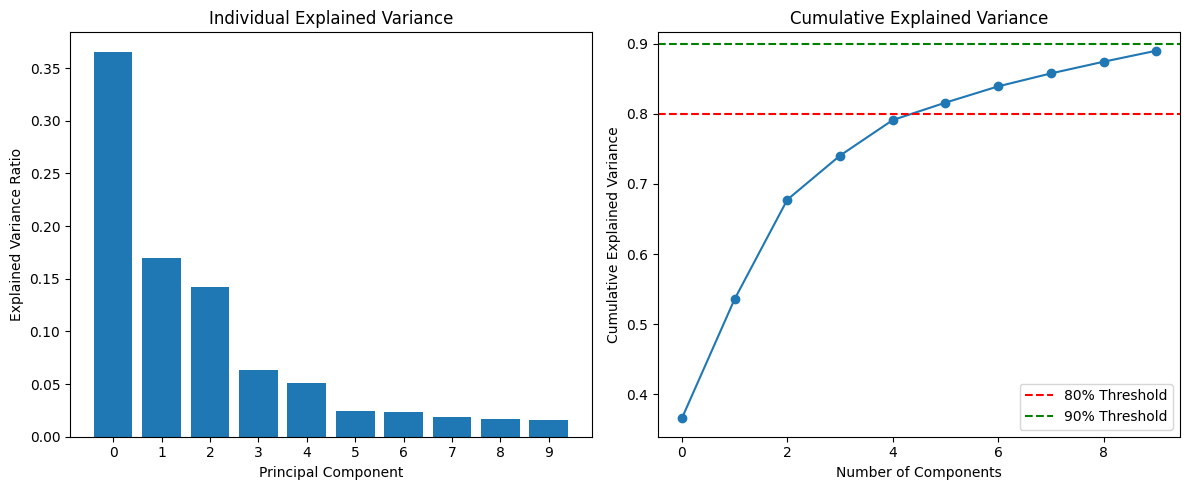

Number of components: 10
Total explained variance: 0.8901
Components needed for 80% variance: 6
Components needed for 90% variance: 1


[ <ipykernel>:7 ] PCA_DATA: μ=0.00 σ=3.52 x̃=-0.07 R=[-35.88,27.20] ℙ=|   █▆  | shape=(104416,10) dtype=float64
[ <ipykernel>:16 ] len(FEATURE_COLS) = 139
[ <ipykernel>:17 ] PCA_OBJ.components_: μ=0.01 σ=0.08 x̃=0.00 R=[-0.30,0.31] ℙ=|  ▄█▃▁ | shape=(10,139) dtype=float64


In [9]:
# PCA
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)
# save pca data
dbg_tensor(PCA_DATA)
np.save(PATH_BASE / "pca.npy", PCA_DATA)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[
	[col for col in DATA_SCALED.columns if col.startswith("activation.")]
]
data_meta.write_ndjson(PATH_BASE / "meta.jsonl")
dbg(len(FEATURE_COLS))
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
pca_cols: list[str] = [f"pc.{i}" for i in range(PCA_DATA.shape[1])]
DF_PCA: pl.DataFrame = pl.DataFrame(PCA_DATA, schema=pca_cols)
DF_PCA = pl.concat([DF_PCA, data_meta], how="horizontal")
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [10]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.beta_hist.hi…",0.132019,0.021744,0.041693,0.026644,0.050231,-0.039893,0.007525,-0.042993,0.002443,-0.043938,0.040912,0.132019,0.001157,0.064796
"""feat.log.gram.col.beta_hist.hi…",-0.131491,-0.023885,-0.029988,-0.027592,-0.058581,0.043806,-0.008661,0.040766,0.002672,0.049681,0.041712,0.131491,0.001168,0.063965
"""feat.log.gram.col.beta_hist.hi…",-0.130876,-0.018614,-0.028844,-0.032396,-0.062058,0.052676,-0.013077,0.043954,0.004689,0.046901,0.043409,0.130876,0.001146,0.063533
"""feat.log.gram.col.beta_hist.hi…",-0.130754,-0.016101,-0.057749,-0.021995,-0.035636,0.02978,0.002459,0.037141,-0.029938,0.037038,0.039859,0.130754,0.00111,0.064495
"""feat.log.gram.col.beta_hist.hi…",-0.12954,-0.02547,-0.019496,-0.0281,-0.065156,0.046702,-0.009547,0.038372,0.007077,0.054098,0.042356,0.12954,0.001163,0.062588
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.gram.row.beta_hist.hist.r…",0.002865,-0.023512,-0.053345,-0.061836,0.314323,0.03835,0.091534,0.028331,0.058157,-0.006211,0.067846,0.314323,0.007407,0.03711
"""feat.first_tok.variance""",0.002493,-0.045873,-0.002241,-0.088058,0.195627,0.085487,0.200255,-0.030599,0.248453,0.280905,0.117999,0.280905,0.009788,0.040381
"""feat.first_tok.std""",-0.001762,-0.051413,-0.011455,-0.088231,0.21202,0.067212,0.202844,-0.033565,0.248602,0.265173,0.118228,0.265173,0.009465,0.042622


In [11]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""first_tok""",0.075287,0.049504,0.118228,0.06668
"""gram""",0.06981,0.03859,0.100537,0.07101
"""log""",0.05608,0.038113,0.100355,0.055813
"""diag""",0.081186,0.066255,0.091967,0.081856
"""markov_transition""",0.047135,0.038061,0.080438,0.042245


/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


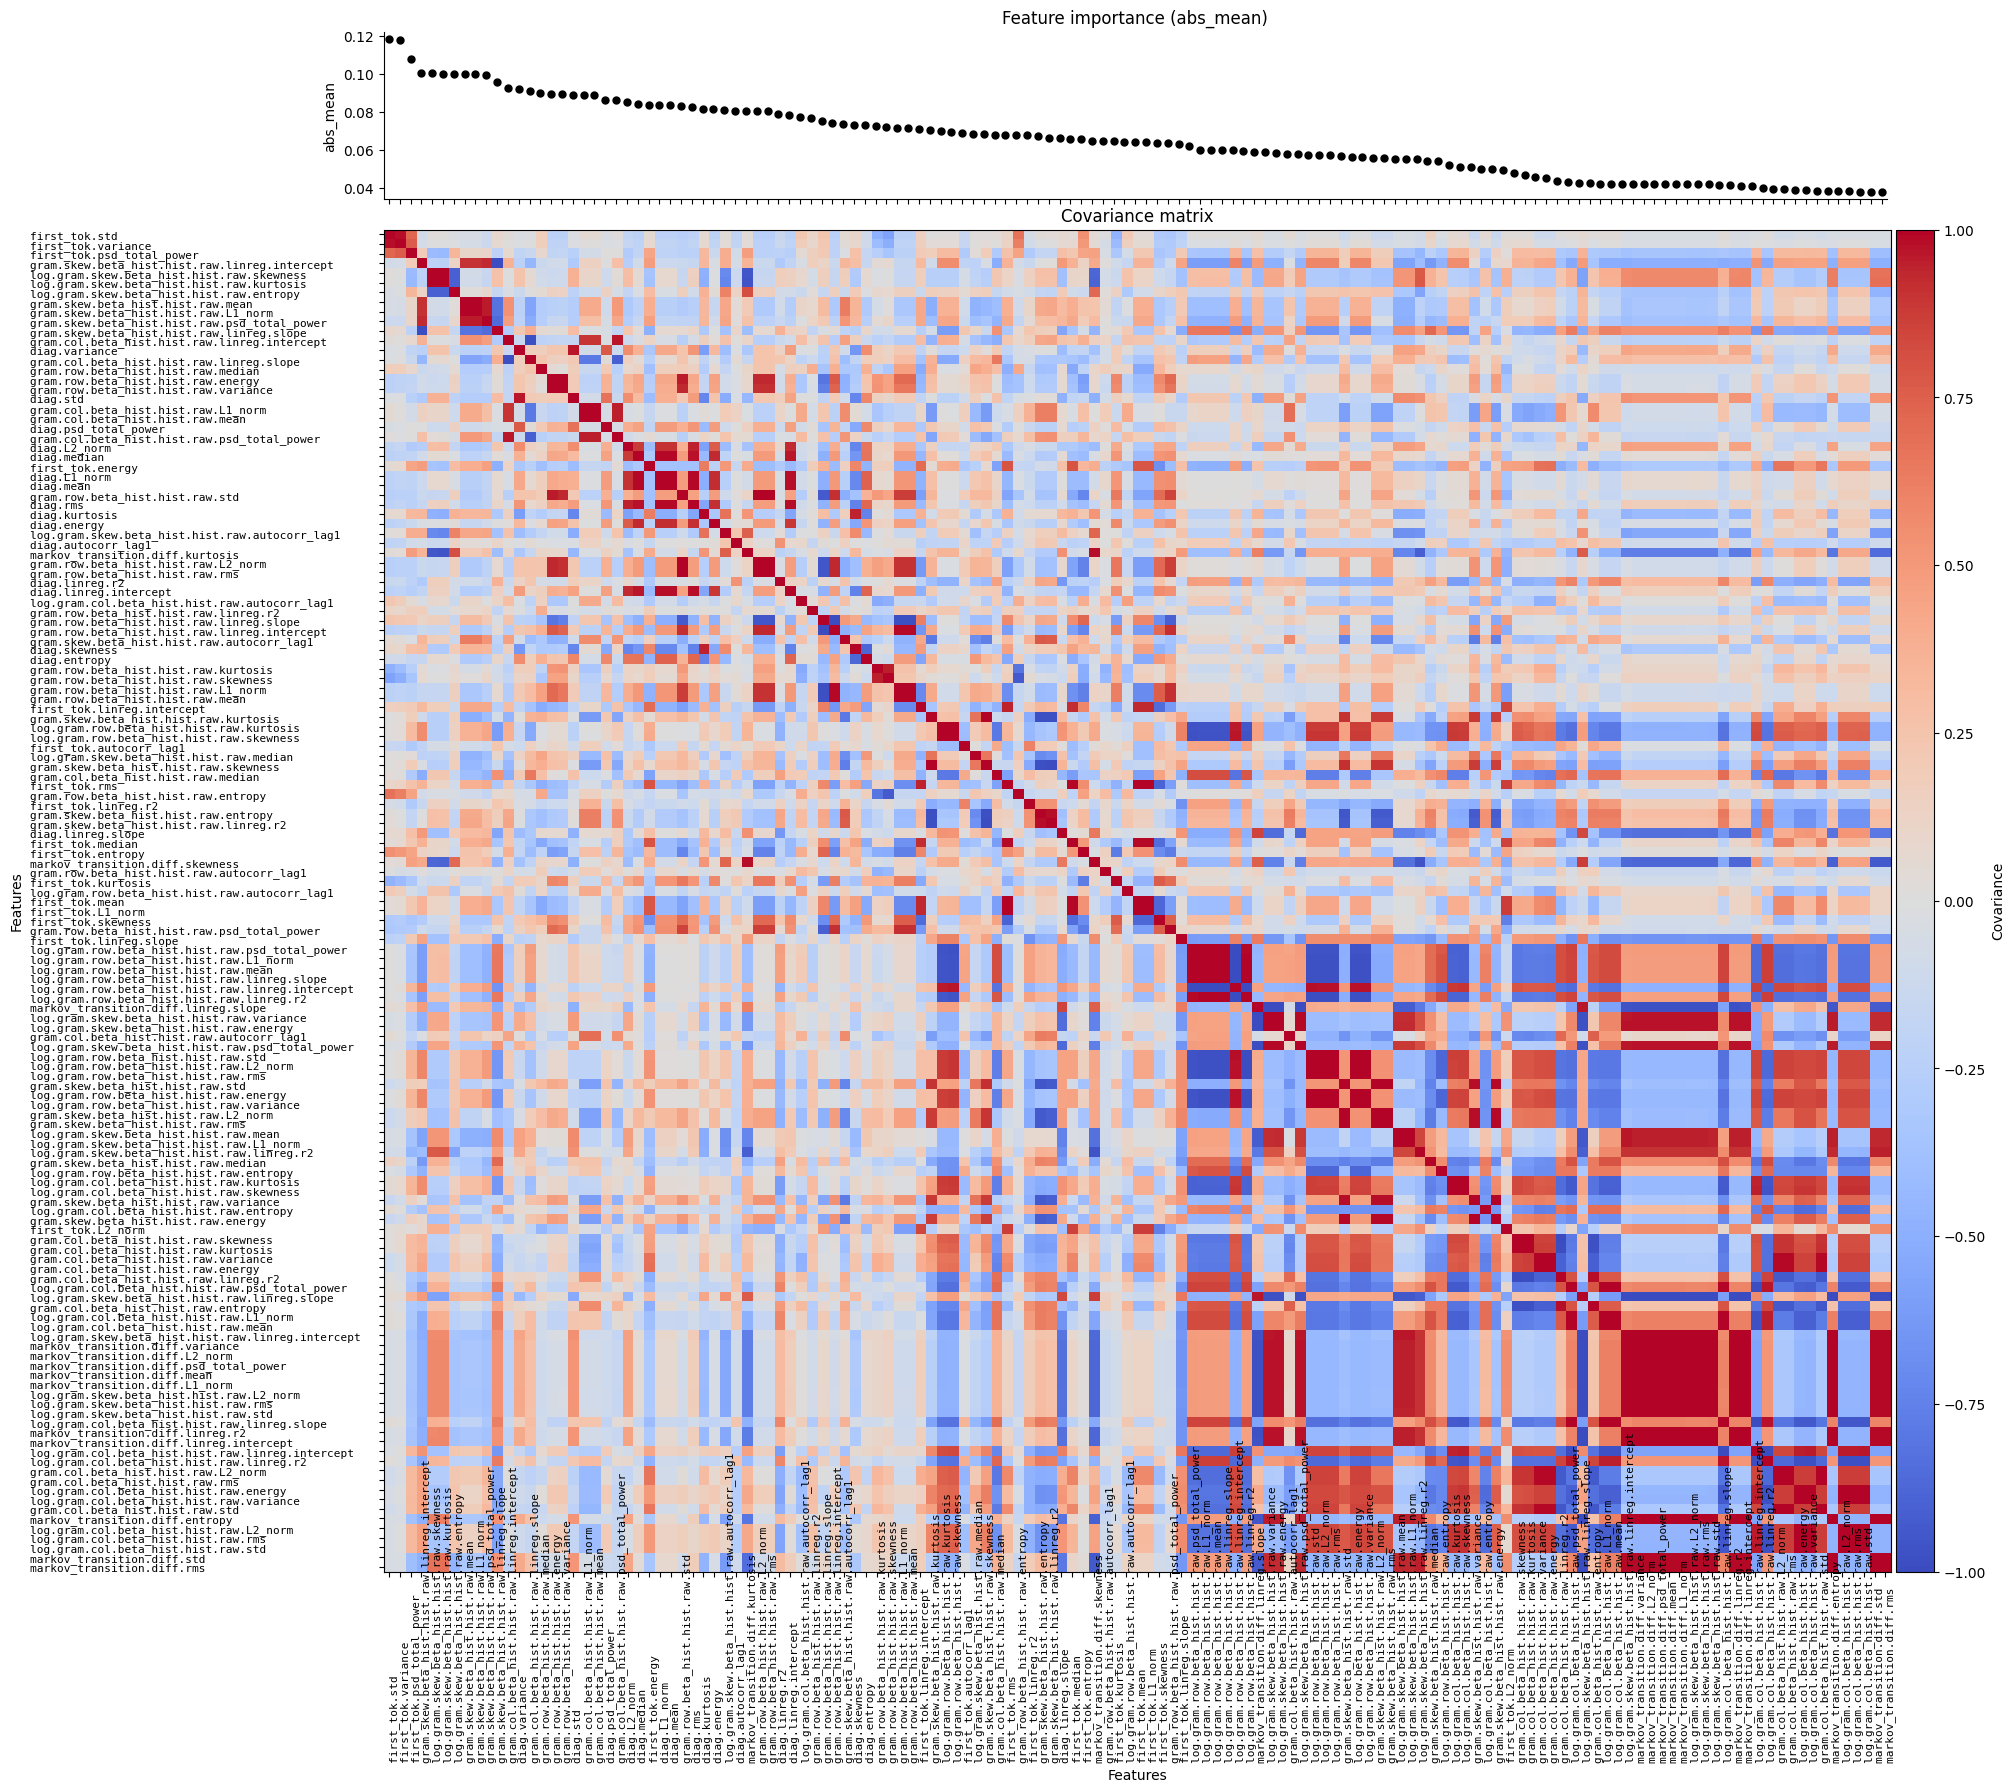

In [12]:
plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metric="abs_mean",
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
)

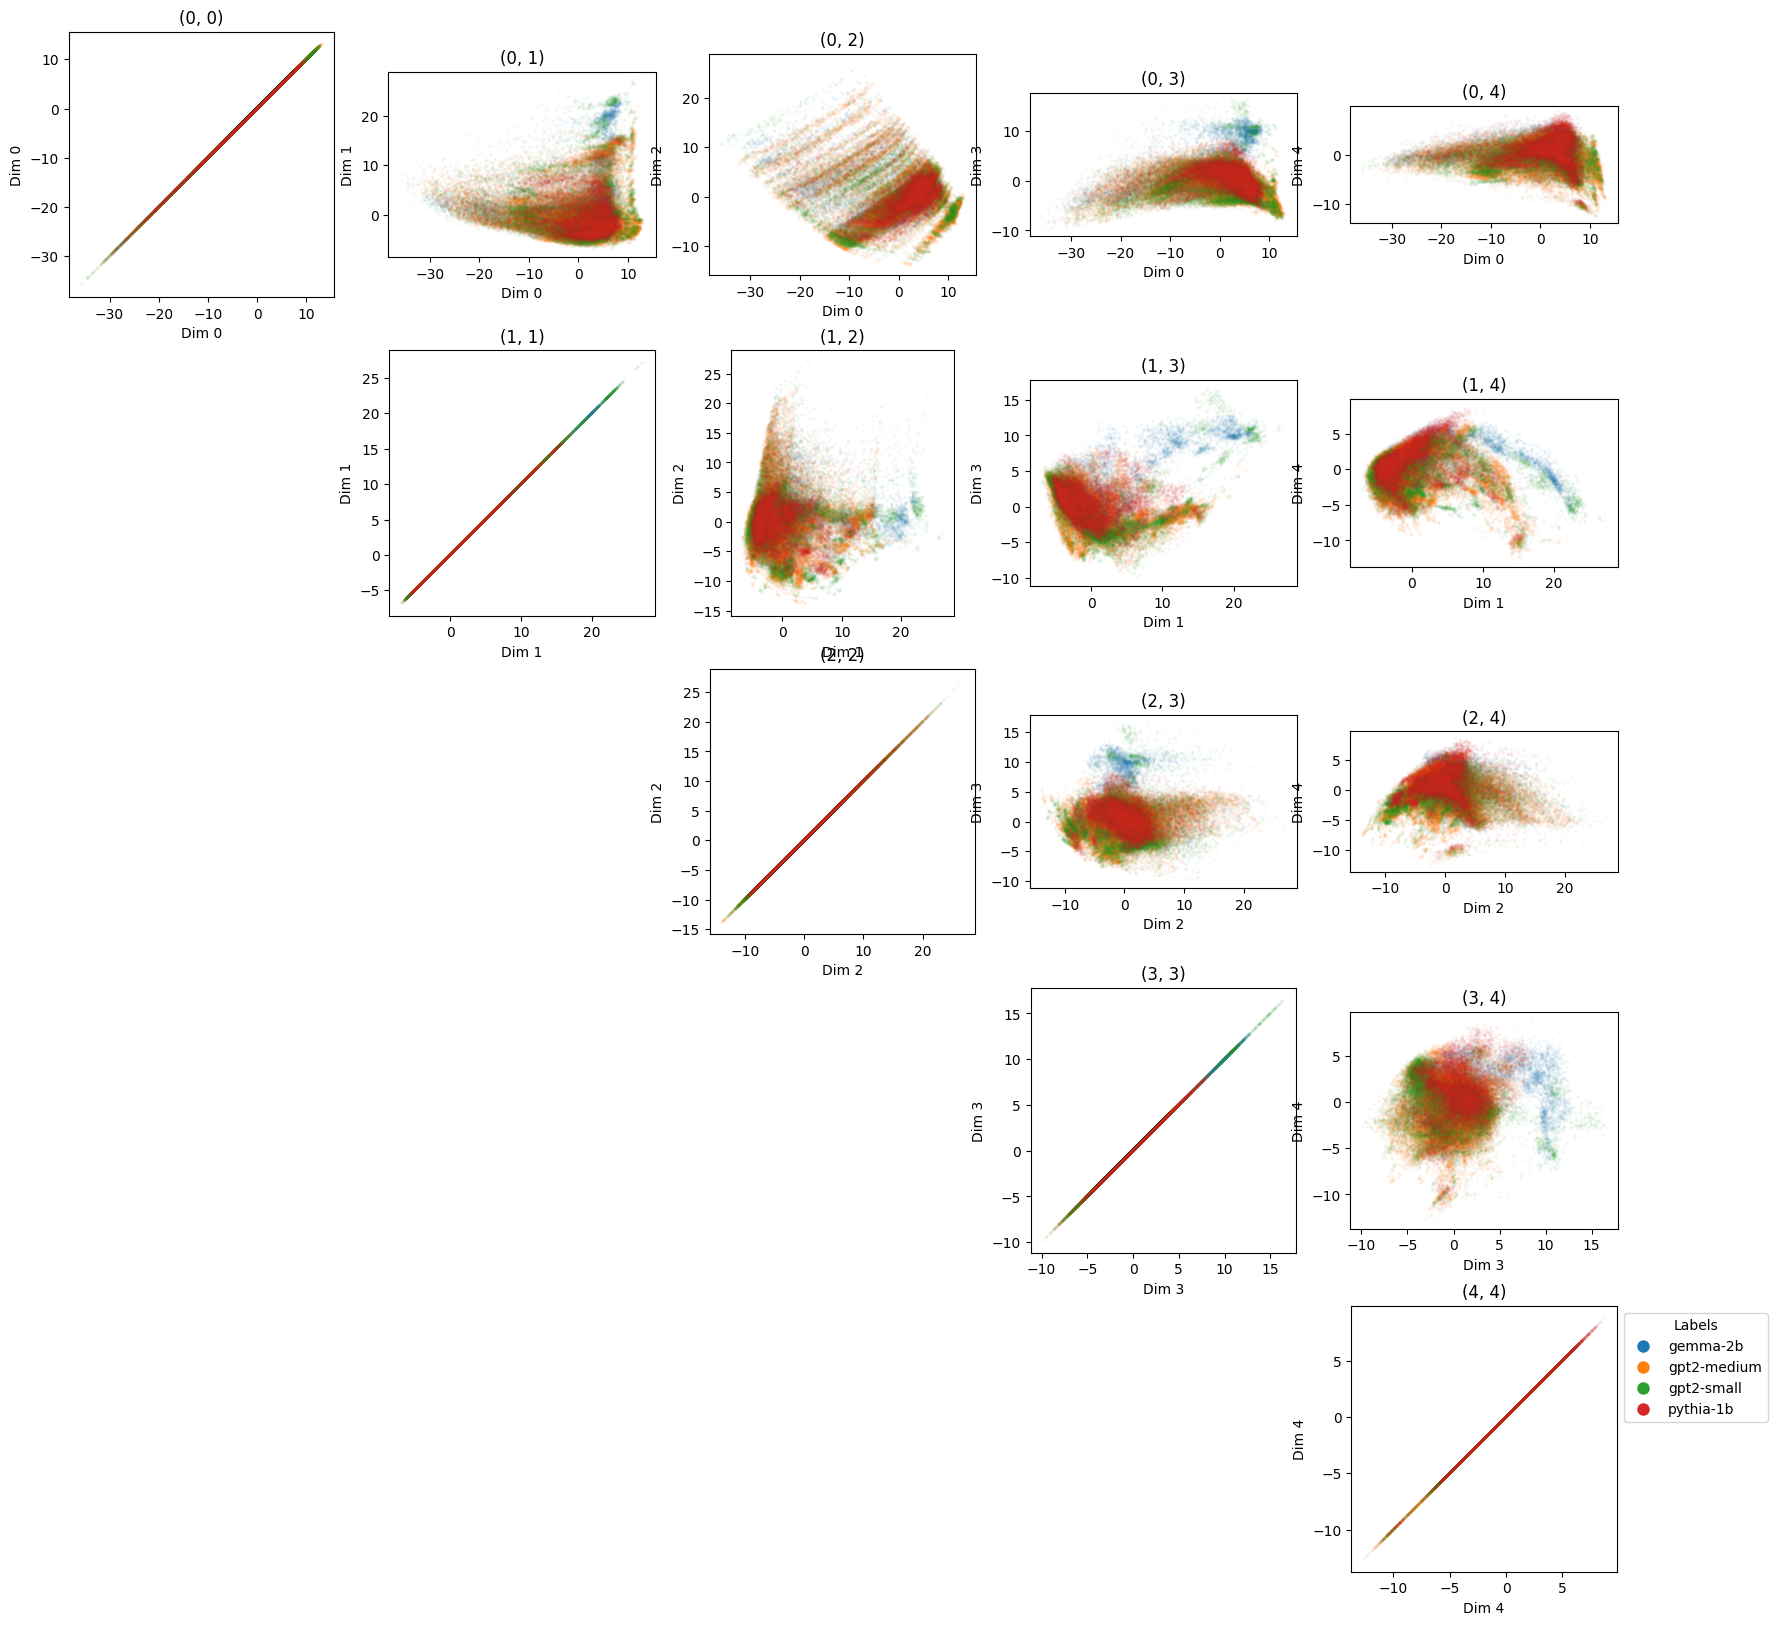

In [13]:
# DATA_REDUCED: pl.DataFrame = DATA_SCALED.select(
# 	[
# 		f for f in DATA_SCALED.columns
# 		if "markov_transition" not in f
# 	]
# )

n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims,
	n_dims,
	figsize=(20, 20),
)
for i in range(0, n_dims):
	for j in range(i, n_dims):
		plot_embedding(
			PCA_DATA,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=5,
			title=f"({i}, {j})",
			ax=embed_ax[i, j],
		)
	for k in range(0, i):
		embed_ax[i, k].axis("off")

# distances between heads

In [14]:
DATA_SCALED

feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.mean,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.gram.col.beta_hist.hist.raw.energy,feat.log.gram.row.beta_hist.hist.raw.variance,activation.head,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.linreg.intercept,activation.n_ctx,feat.log.gram.row.beta_hist.hist.raw.L2_norm,feat.diag.variance,feat.log.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.first_tok.psd_total_power,feat.first_tok.entropy,feat.markov_transition.diff.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.rms,feat.diag.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.diag.linreg.r2,activation.prompt,feat.gram.col.beta_hist.hist.raw.linreg.slope,activation.cls,feat.log.gram.skew.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.entropy,feat.first_tok.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.diff.kurtosis,…,feat.gram.skew.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.first_tok.rms,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.std,feat.diag.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.first_tok.energy,feat.gram.col.beta_hist.hist.raw.std,feat.log.gram.row.beta_hist.hist.raw.entropy,feat.first_tok.std,feat.log.gram.col.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.linreg.r2,activation.cache_key,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.entropy,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.linreg.r2,feat.diag.skewness,feat.diag.entropy,feat.gram.skew.beta_hist.hist.raw.L1_norm,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.log.gram.row.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.mean,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.row.beta_hist.hist.raw.mean,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.std,feat.gram.skew.beta_hist.hist.raw.energy,feat.log.gram.col.beta_hist.hist.raw.variance,feat.log.gram.col.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.rms,activation.model,feat.gram.skew.beta_hist.hist.raw.skewness
f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
-0.724653,0.989938,-0.465602,-0.818746,-0.337689,-0.283626,0.892255,0.86094,0,0.76821,-1.11468,0.814896,109,0.839435,1.435507,-0.780488,-2.15458,-0.7244,-1.580293,0.489934,0.604305,-0.264634,0.473904,-0.82196,0.442892,1.450932,0.970525,-0.986983,"""MjWkadUxH4Z5nfLEFtUc1w""",0.159702,"""gemma-2b:L0:H0""",-0.266664,-1.127713,0.310588,0.634667,-0.008704,-0.057261,…,0.987323,0.659782,0.274522,0.992118,0.836533,0.045931,4.061082,0.075595,0.878836,-0.682661,0.833364,0.967734,-0.485985,-0.792824,"""blocks.0.attn.hook_pattern""",-0.554036,-0.687398,-0.313089,-0.967268,-0.30592,-0.863237,-1.217447,0.963007,-0.692114,0.796153,0.839435,-0.288697,-0.32214,-0.7244,0.28935,1.023283,0.964072,0.988711,0.970525,-0.266664,"""gemma-2b""",1.141701
-0.724653,1.070734,-0.856179,-0.994693,-0.797421,0.313219,1.489322,0.86094,1,0.846132,-1.34125,0.971801,109,0.839435,-0.407666,-0.933958,-2.15458,

In [24]:

head_dists = build_distance_tensor(
	DF_PCA,
	feature_prefix="pc.",
)
dbg_tensor(head_dists.distances)
head_dists_mean = head_dists.distances.mean(axis=-1)
dbg_tensor(head_dists_mean)
print()

[ <ipykernel>:6 ] head_dists.distances: μ=11.56 σ=5.78 x̃=10.62 R=[0.00,43.31] ℙ=|▃█▄▁   | shape=(800,800,128) dtype=float64
[ <ipykernel>:8 ] head_dists_mean: μ=11.56 σ=5.29 x̃=10.55 R=[0.00,36.34] ℙ=|▁█▅▂   | shape=(800,800) dtype=float64


In [ ]:
from muutils.json_serialize import json_serialize
import json

with open(PATH_BASE / "head_dists.json", "w") as f:
	json.dump(
		json_serialize(
			dict(
				labels=head_dists.cls_values,
				dists=head_dists_mean,
			)
		),
		f,
	)

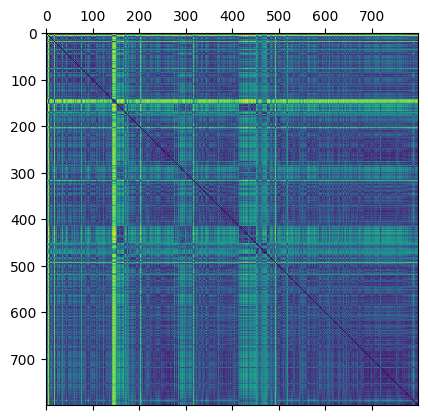

In [ ]:
plt.matshow(head_dists_mean)

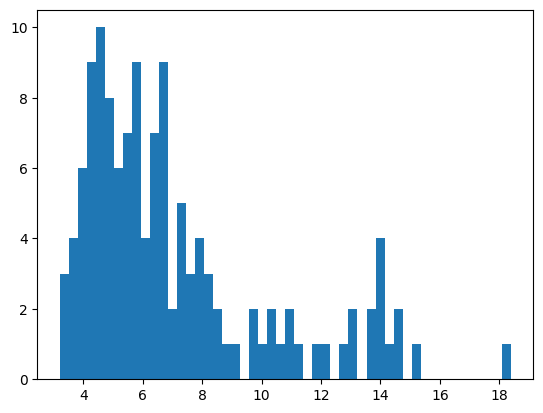

In [18]:
plt.hist(
	head_dists.distances[0, 1],
	bins=50,
)
print()

In [49]:
def load_attnpedia(
	path: str | Path = Path("../data/atnn-pedia.json"),
) -> dict[str, str]:
	"""Load the attnpedia data."""
	data_raw: dict = json.load(open(path, "r"))
	model_name: str = data_raw["model"]

	data: list[dict] = list()
	for head_cls in data_raw["classes"]:
		for h in head_cls["heads"]:
			data.append(
				{
					"head": f"{model_name}:L{h['L']}:H{h['H']}",
					"type": head_cls["type"],
				}
			)

	return {row["head"]: row["type"] for row in data}


ATTN_PEDIA: dict[str, str] = load_attnpedia()

/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 822 with accuracies 
[1.01063943e-14 2.32647282e-06 7.21516029e-06 4.25098926e-07]
not reaching the requested tolerance 2.4139881134033203e-06.
Use iteration 822 inst

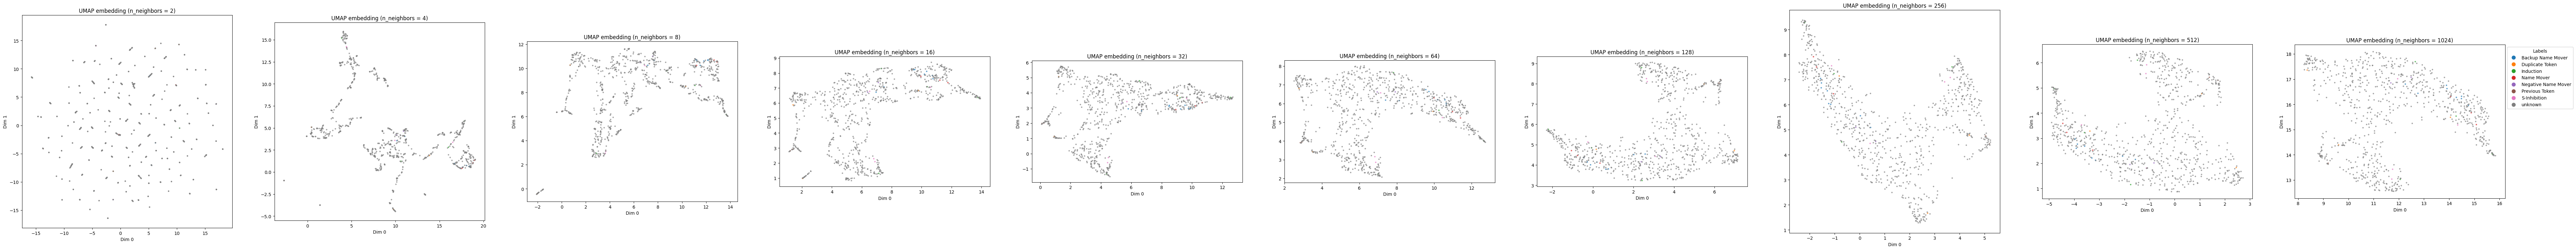

In [50]:
import umap

n_neighbors_lst: list[int] = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
fig, ax = plt.subplots(
	nrows=1,
	ncols=len(n_neighbors_lst),
	figsize=(10 * len(n_neighbors_lst), 10),
)
for i, n_neighbors in enumerate(n_neighbors_lst):
	reducer: umap.UMAP = umap.UMAP(
		n_components=2,
		metric="precomputed",
		init="spectral",
		n_neighbors=n_neighbors,
		min_dist=0.1,
		random_state=0,
	)
	embedding: np.ndarray = reducer.fit_transform(head_dists_mean)

	# scatter plot
	plot_embedding(
		embedding,
		# labels=pl.Series([f.split(":")[0] for f in head_dists.cls_values]),
		labels=pl.Series([ATTN_PEDIA.get(f, "unknown") for f in head_dists.cls_values]),
		dims=(0, 1),
		alpha=0.7,
		marker_size=10,
		title=f"UMAP embedding ({n_neighbors = })",
		ax=ax[i],
	)
plt.show()

# plt.figure(figsize=(8, 6))
# plt.scatter(embedding[:, 0], embedding[:, 1], s=10)  # no explicit colours
# plt.xlabel("UMAP 0")
# plt.ylabel("UMAP 1")
# plt.title("UMAP embedding")
# plt.tight_layout()
# plt.show()

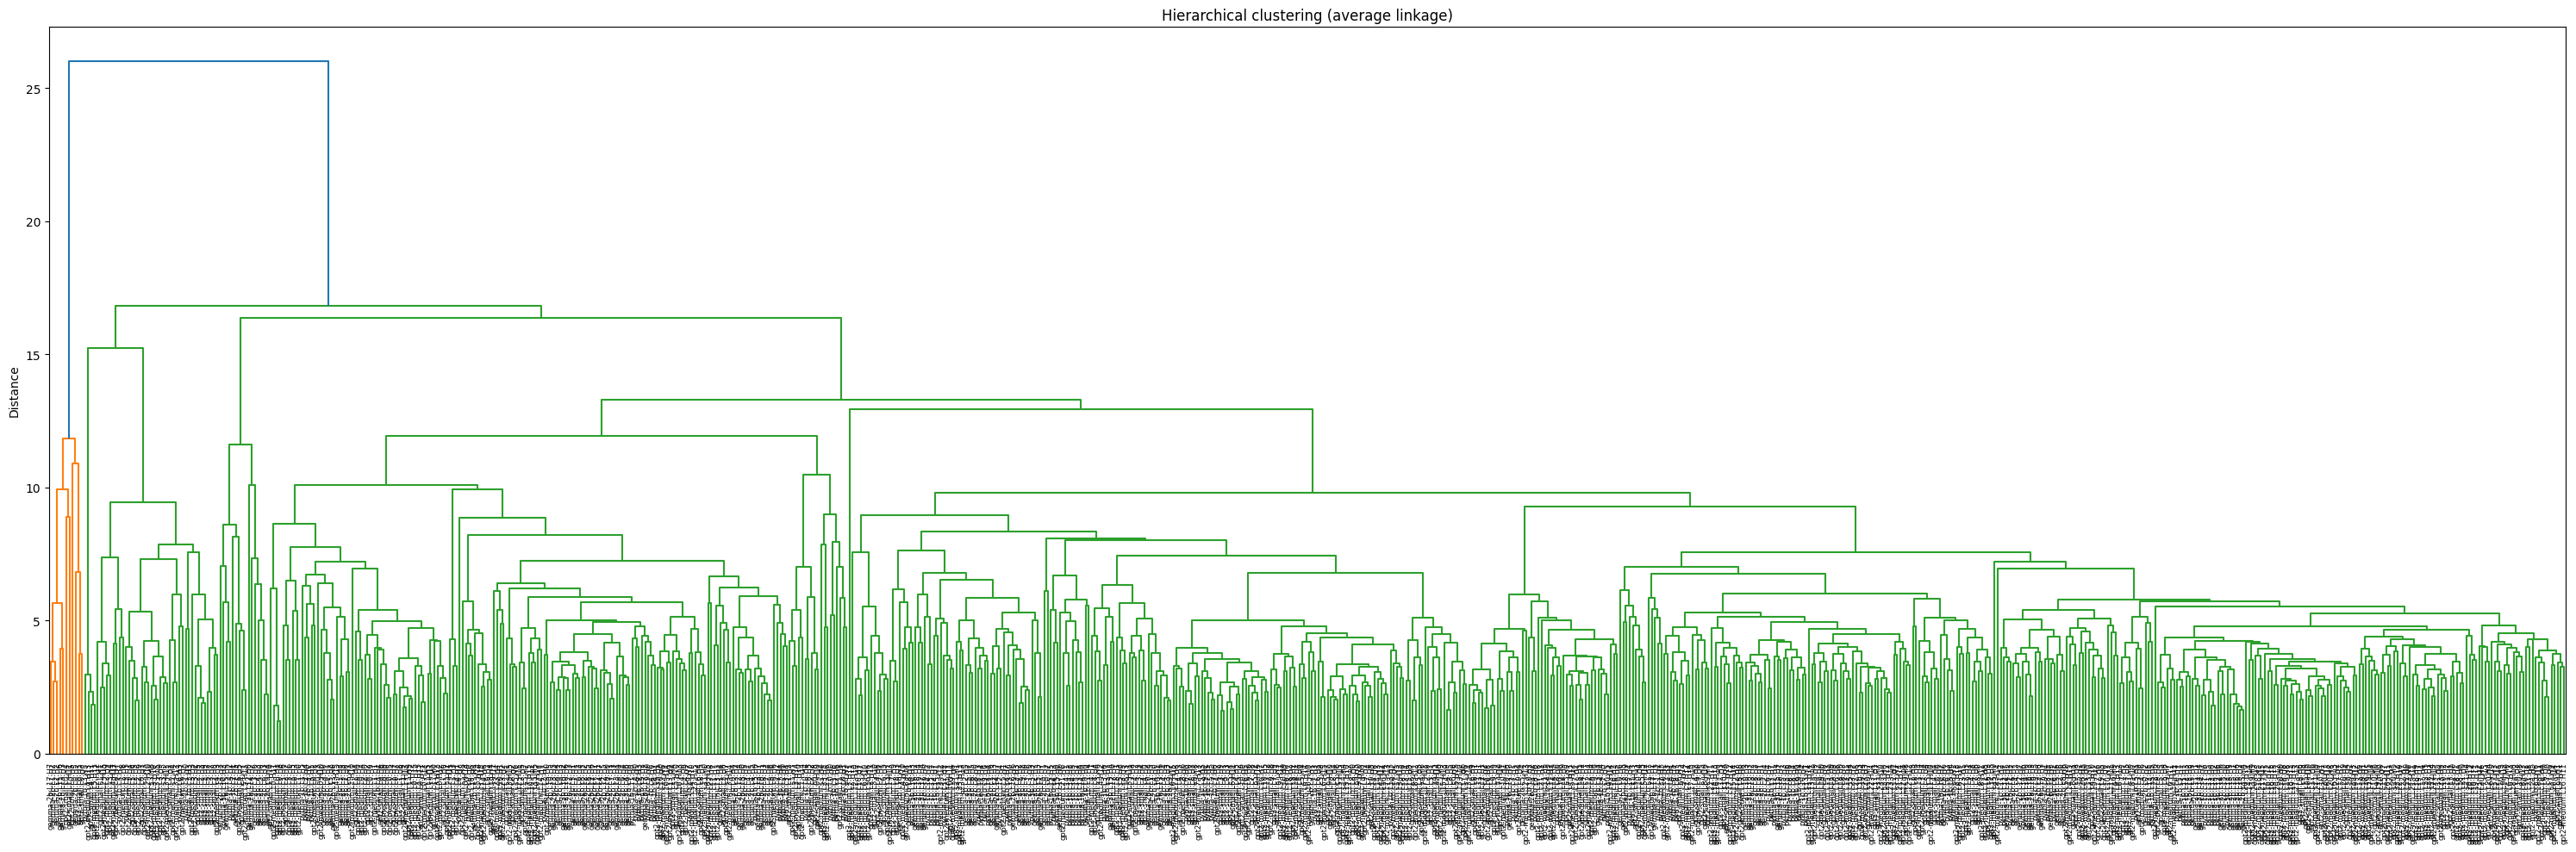

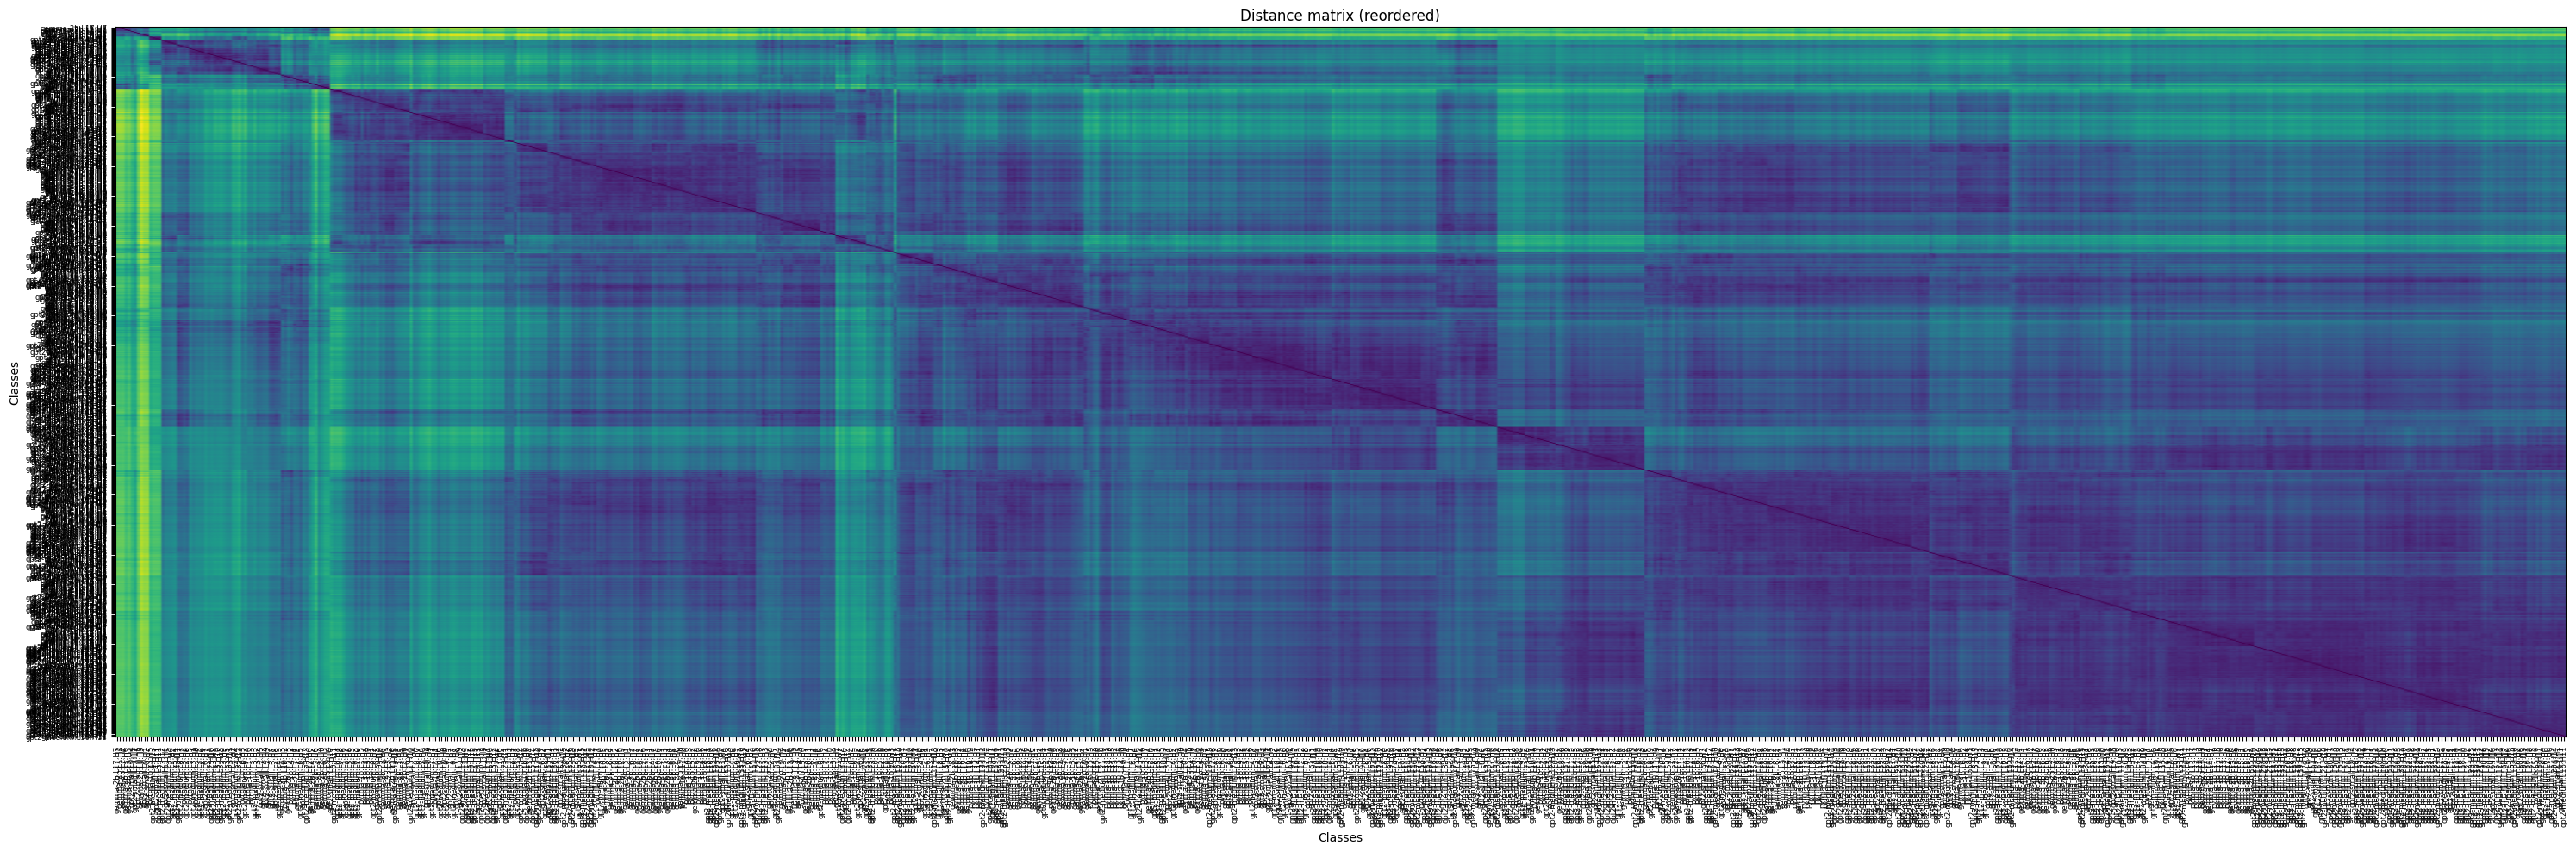

array([[4.17000000e+02, 4.24000000e+02, 1.22315135e+00, 2.00000000e+00],
       [1.89000000e+02, 1.93000000e+02, 1.61594823e+00, 2.00000000e+00],
       [1.22000000e+02, 1.24000000e+02, 1.62656278e+00, 2.00000000e+00],
       ...,
       [1.59000000e+03, 1.59400000e+03, 1.63839509e+01, 7.46000000e+02],
       [1.59500000e+03, 1.59600000e+03, 1.68106368e+01, 7.89000000e+02],
       [1.59100000e+03, 1.59700000e+03, 2.59986450e+01, 8.00000000e+02]])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform


def plot_hclust(
	dist_mat: np.ndarray,
	labels: list[str],
	*,
	method: str = "average",
	leaf_font_size: int = 6,
	truncate: int | None = None,
	show_heatmap: bool = True,
	figsize: tuple[int, int] | None = None,
) -> np.ndarray:
	"""
	Make a dendrogram (and optional reordered heat-map) from a distance matrix.

	Parameters
	----------
	dist_mat : (h, h) ndarray  – symmetric, zero diagonal
	labels   : list[str]      – length h, row/column names
	method   : str            – linkage criterion (avg/single/complete/ward…)
	leaf_font_size : int      – font size used for tick labels
	truncate : int | None     – cap the dendrogram to the last *truncate* leaves
	show_heatmap : bool       – skip heat-map when h is too large
	figsize  : tuple[int, int]|None – if None, size is chosen automatically

	Returns
	-------
	Z : ndarray               – SciPy linkage matrix (h-1, 4)
	"""
	h: int = dist_mat.shape[0]
	if dist_mat.shape != (h, h):
		raise ValueError("dist_mat must be square")
	if len(labels) != h:
		raise ValueError("labels length must match dist_mat")
	if not np.allclose(dist_mat, dist_mat.T):
		raise ValueError("dist_mat must be symmetric")
	if not np.all(np.diag(dist_mat) == 0):
		raise ValueError("dist_mat diagonal must be zero")

	# linkage --------------------------------------------------------------
	condensed: np.ndarray = squareform(dist_mat, checks=False)
	Z: np.ndarray = linkage(condensed, method=method)

	# pick a reasonable figure size ---------------------------------------
	if figsize is None:
		width = max(10, min(0.05 * h, 30))  # 20 labels → 11 in, 800 → 30 in
		height = 5 if not show_heatmap else 10
		figsize = (width, height)

	# dendrogram -----------------------------------------------------------
	plt.figure(figsize=figsize)
	dend_kw: dict[str, object] = {
		"labels": labels,
		"leaf_rotation": 90,
		"leaf_font_size": leaf_font_size,
		"distance_sort": "ascending",
	}
	if truncate is not None:
		dend_kw.update({"truncate_mode": "lastp", "p": truncate})

	dendro = dendrogram(Z, **dend_kw)
	plt.ylabel("Distance")
	plt.title(f"Hierarchical clustering ({method} linkage)")
	plt.tight_layout()
	plt.show()

	# heat-map -------------------------------------------------------------
	if show_heatmap:
		order: list[int] = dendro["leaves"]
		reordered: np.ndarray = dist_mat[np.ix_(order, order)]

		plt.figure(figsize=figsize)
		plt.imshow(reordered, aspect="auto")  # default colormap
		plt.xticks(
			np.arange(h),
			[labels[i] for i in order],
			rotation=90,
			fontsize=leaf_font_size,
		)
		plt.yticks(
			np.arange(h),
			[labels[i] for i in order],
			fontsize=leaf_font_size,
		)
		plt.xlabel("Classes")
		plt.ylabel("Classes")
		plt.title("Distance matrix (reordered)")
		plt.tight_layout()
		plt.show()

	return Z


plot_hclust(
	head_dists.distances.mean(axis=-1),
	labels=head_dists.cls_values,
)